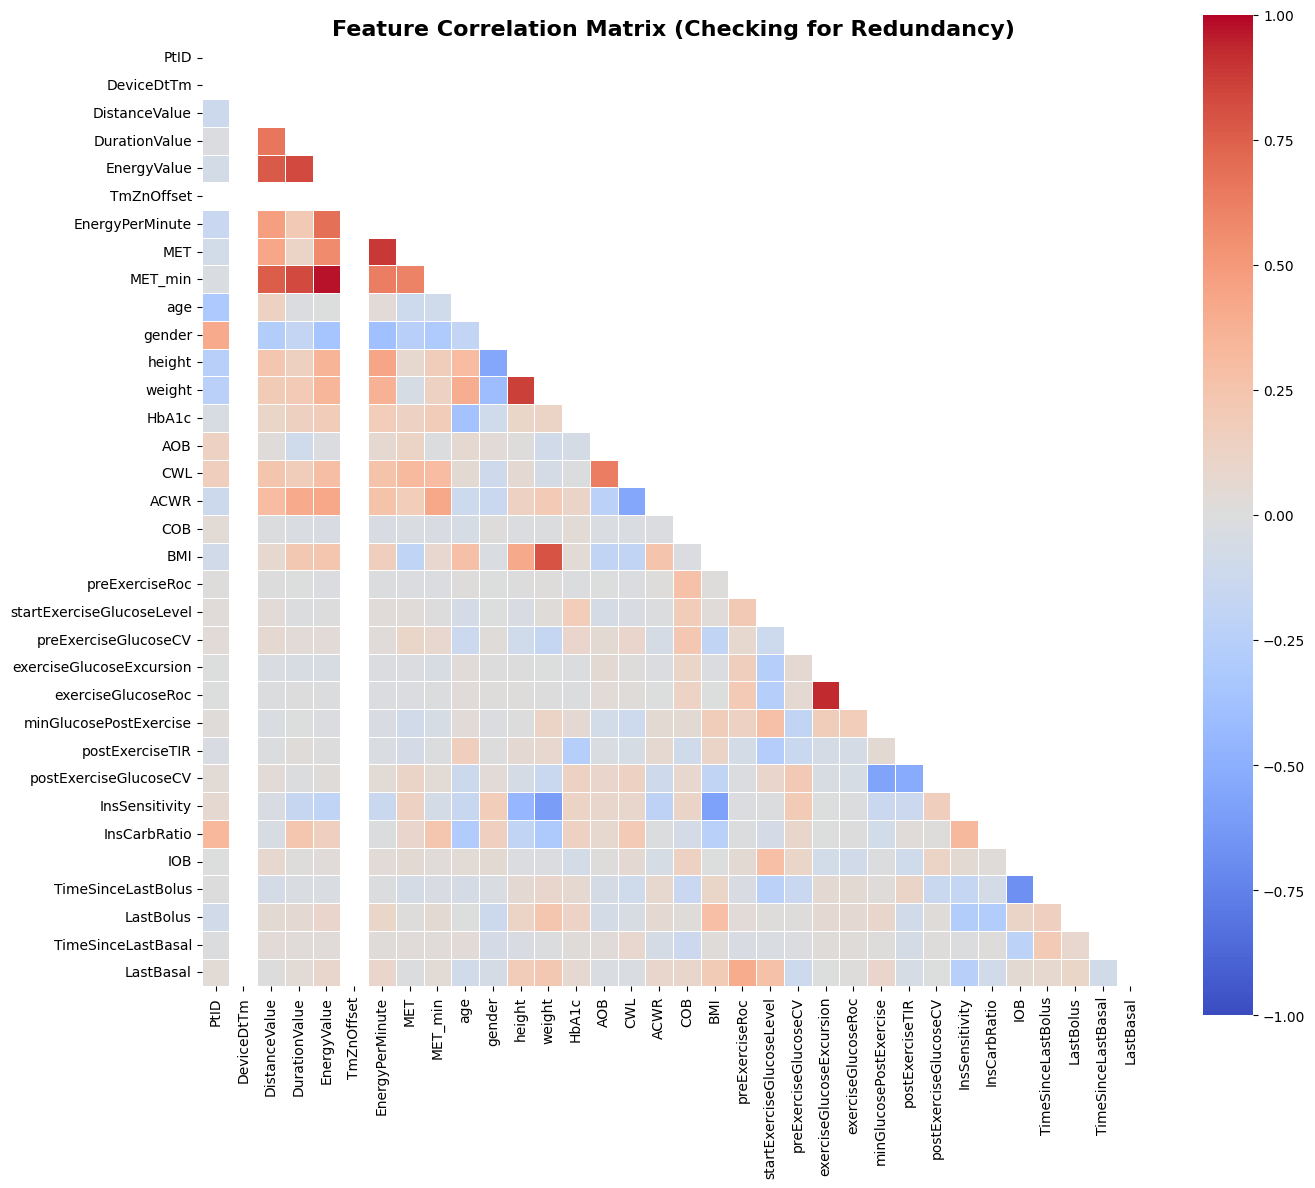

⚠️ HIGHLY CORRELATED PAIRS (Consider dropping one from each pair):
EnergyValue               MET_min               0.971871
exerciseGlucoseExcursion  exerciseGlucoseRoc    0.927874
EnergyPerMinute           MET                   0.888884
height                    weight                0.865593
dtype: float64


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np

file_path = os.path.join("tables", "exerciseTableForBN_python.parquet")
exerciseTable = pd.read_parquet(file_path)

# 1. Grab only the numeric columns from your ORIGINAL continuous table
numeric_data = exerciseTable.select_dtypes(include=['float64', 'int64'])

# 2. Calculate the Spearman correlation matrix
corr_matrix = numeric_data.corr(method='spearman')

# 3. Plot the Heatmap
plt.figure(figsize=(14, 12))

# We use a mask to hide the upper triangle since it's a mirror image
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', 
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5)

plt.title('Feature Correlation Matrix (Checking for Redundancy)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Print the top highly correlated pairs (Threshold > 0.85)
print("⚠️ HIGHLY CORRELATED PAIRS (Consider dropping one from each pair):")
stacked_corr = corr_matrix.abs().unstack()
high_corr = stacked_corr[(stacked_corr > 0.85) & (stacked_corr < 1.0)]
print(high_corr.drop_duplicates().sort_values(ascending=False))